In [5]:
!pip install shap

In [6]:
import shap
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [7]:
import os

#unziping
import zipfile
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
  zip_ref.extractall("archive")

fake_dataset = pd.read_csv("archive/Fake.csv")
true_dataset = pd.read_csv("archive/True.csv")

fake_dataset["label"] = 0   #fake label 0
true_dataset["label"] = 1   #true label 1

dataset = pd.concat([fake_dataset, true_dataset], axis=0)

dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)    #shuffing

dataset.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [8]:
#combining the generated dataset
dataset["content"] = dataset["title"] + " " + dataset["text"]
dataset["content"].head()

X = dataset["content"]
y = dataset["label"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#removing too common english words and those appearing more than 70% doc
#as not used in detecting fake or real
vectorizer = TfidfVectorizer(stop_words = "english" , max_df = 0.7)

### always [training data: fit_transform()] [test data: transform()]
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)


(35918, 111683)


In [10]:
### LOGISTIC REGRESSION
#predicts probability that some thing belongs to a specific category 0/1
logistic_regression_model = LogisticRegression()

logistic_regression_model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = logistic_regression_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy(How many articles were correctly classified) :", accuracy)

Accuracy(How many articles were correctly classified) : 0.984521158129176


In [24]:
#extracting names of features instead of numbers
feature_names = vectorizer.get_feature_names_out()

#object used for computing shap values
explainer = shap.Explainer(logistic_regression_model, X_train_tfidf, feature_names=feature_names)

In [25]:
#taking first test article

sample_index = 0
sample_article = X_test.iloc[sample_index]
print(sample_article[:500])

 It’s Really Happening: Trump Adviser Lays Out Plan For National Muslim Registry Well, that didn t take long. In the short time since Americans kinda-sorta elected Donald Trump to be Pussygrabber-in-Chief, Trump has appointed a bona fide white nationalist to a high-level position and perform numerous other actions that months ago were considered extremely unlikely nightmare scenarios   and the latest seems to be that the Muslim registry the media told us Trump was not serious about might actuall


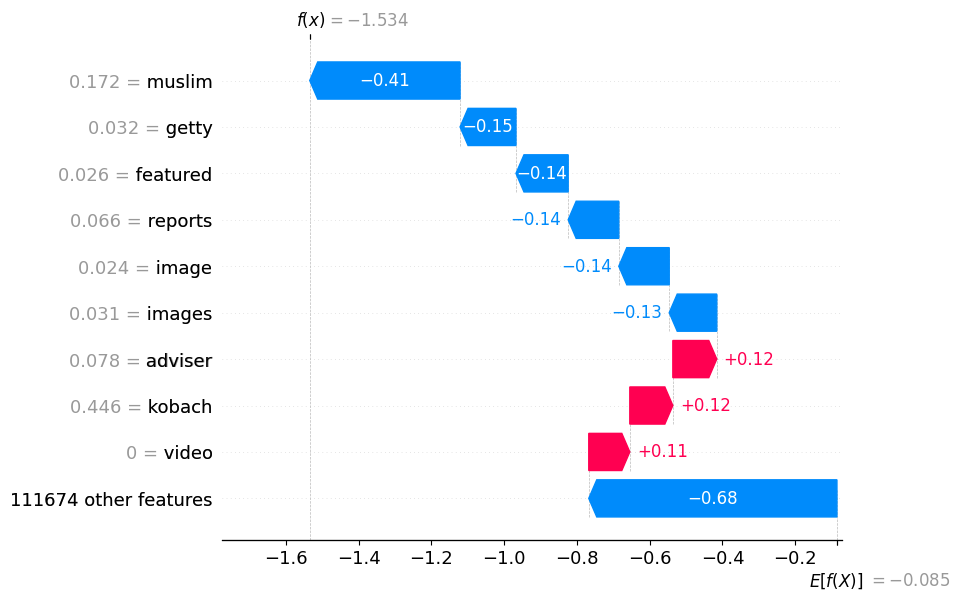

In [26]:
#generating shap values for test article
shap_values_test = explainer( X_test_tfidf[sample_index] )

shap.plots.waterfall( shap_values_test[0] )

Here above instead of directly article being classified as fake, now we can also see words due to which it is classified as fake.
This is called Local Explainability

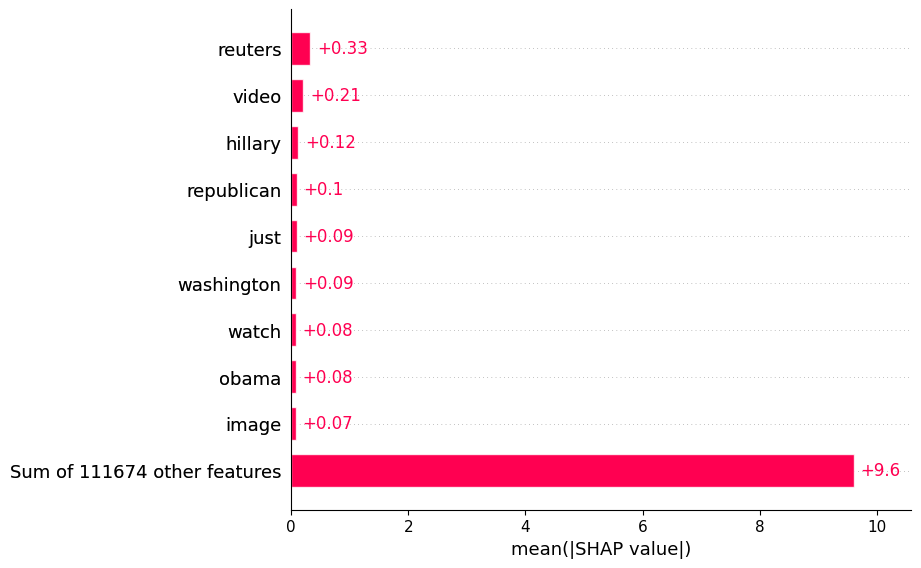

In [29]:
#testing for multiple samples
shap_values_batch = explainer( X_test_tfidf[:100] )

#plot for 100 articles together
shap.plots.bar( shap_values_batch )

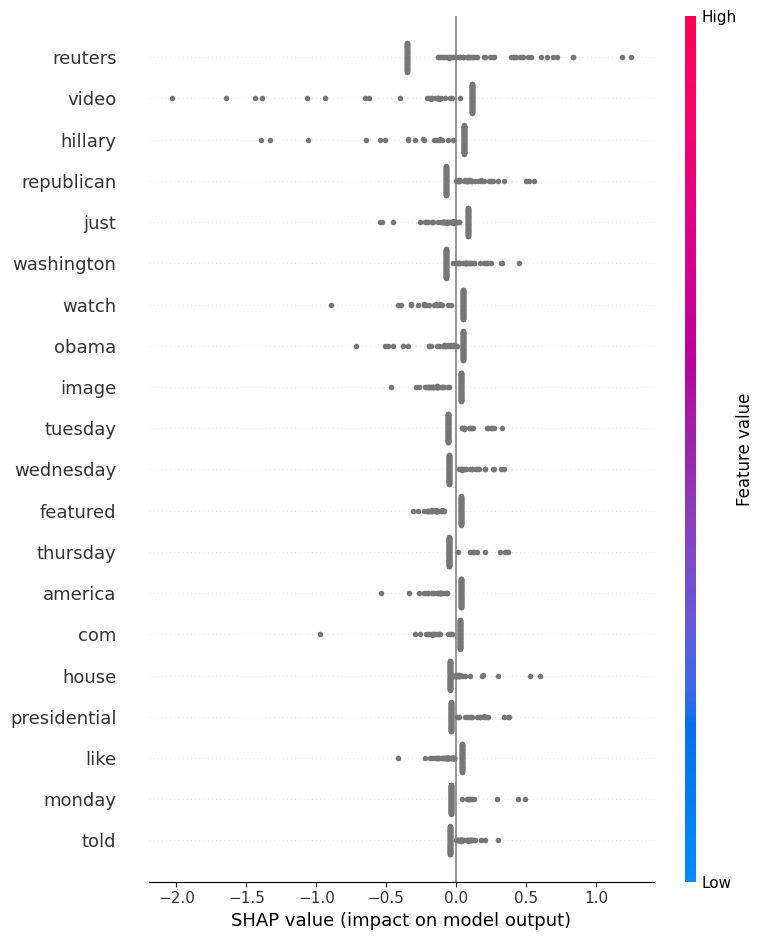

In [32]:
shap.summary_plot( shap_values_batch.values, X_test_tfidf[:100] , feature_names = feature_names )

Each dot represents an article and represent shap value for that article

In [34]:
#avg shap importance for every word
importance = np.abs(shap_values_batch.values).mean(axis=0)

#top 20 imp words
top_indices = np.argsort(importance)[::-1][:20]

for each_index in top_indices:
    print(feature_names[each_index], " : ", importance[each_index] )

reuters  :  0.327885788800377
video  :  0.20659283164181058
hillary  :  0.1241851232806053
republican  :  0.10022834872789495
just  :  0.09358994809859629
washington  :  0.08862265010576705
watch  :  0.0836009705406107
obama  :  0.0794859161037791
image  :  0.07414555799507365
tuesday  :  0.07169525496088133
wednesday  :  0.06864357119356013
featured  :  0.06670490045811169
thursday  :  0.06666102441097646
america  :  0.0609669855876746
com  :  0.05973745323526237
house  :  0.05865566976860274
presidential  :  0.05862141399344518
like  :  0.05734024782314626
monday  :  0.05511269424737584
told  :  0.05157536374903224


Observations

1. SHAP provides local explanations for individual predictions
2. The model relies heavily on a small set of highly informative words
3. Sensational and emotionally charged terms contribute strongly toward fake-news predictions
4. Fact based and source oriented terms contribute toward real-news predictions
5. Explainability improves model transparency and trustworthiness